# Phase 3 — Exploratory Data Analysis & Statistical Analysis
**InterveneAI · data/processed/customer_features_v3.parquet (348,767 stacked customer-snapshot rows)**

Objective: describe the target, quantify class imbalance, characterise feature
distributions, and measure how recency / frequency / monetary / behavioural
features relate to `purchased_next_60_days` — with descriptive statistics,
grouped target rates, confidence intervals, hypothesis tests and effect sizes
where appropriate.

Contents: 1. Target distribution · 2. Class imbalance · 3. Feature distributions ·
4. Recency vs future purchase · 5. Purchase frequency vs future purchase ·
6. Monetary value vs future purchase · 7. Behavioural features vs target ·
8. Correlation analysis · 9. Temporal target stability · 10. Outliers · Key Findings

## How to read this notebook (association is not causation)
Every result below is observational. Each section therefore closes with a
three-level reading:
- **Observed association** — what the numbers/plots show descriptively.
- **Statistical evidence** — CIs, tests and effect sizes that quantify sampling
  uncertainty around that association.
- **Causal interpretation** — none is warranted here: no randomisation, no
  adjustment for confounders (e.g. tenure, acquisition channel, seasonality),
  so we make **no causal claims** anywhere in this notebook.

Two further caveats apply to all inferential statistics:
1. Rows are stacked **(customer, snapshot)** combinations — the same customer
   appears in several monthly snapshots. Tests that assume independent
   observations (chi-square, Mann–Whitney, z-tests) are therefore
   **optimistic**; treat p-values as descriptive support, not exact inference.
2. With ~349k rows, trivial differences are "significant". **Effect sizes and
   confidence intervals** carry the interpretation, not p-values.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats as sstats
from statsmodels.stats.proportion import (
    proportion_confint, proportions_ztest, confint_proportions_2indep)

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12,
                     "axes.labelsize": 11})
pd.options.display.float_format = "{:.6f}".format

candidates = [Path("data/processed/customer_features_v3.parquet"),
              Path("../data/processed/customer_features_v3.parquet")]
DATA_PATH = next(p for p in candidates if p.exists())
df = pd.read_parquet(DATA_PATH)
df["snapshot_date"] = pd.to_datetime(df["snapshot_date"])
y = df["purchased_next_60_days"]
FEATURES = ["recency_days", "purchase_count_30d", "purchase_count_90d",
            "purchase_count_180d", "total_spend_180d", "avg_order_value_180d",
            "days_since_previous_purchase", "avg_days_between_orders",
            "purchase_velocity_30d", "purchase_velocity_90d"]

def grouped_rates(data, group_col, target="purchased_next_60_days", alpha=0.05):
    "Counts, target rate and Wilson CI per group."
    g = data.groupby(group_col, observed=False)[target].agg(["count", "sum", "mean"])
    g = g.rename(columns={"sum": "positives", "mean": "rate"})
    ci = proportion_confint(g["positives"], g["count"], alpha=alpha, method="wilson")
    g["ci_lo"], g["ci_hi"] = np.asarray(ci[0]), np.asarray(ci[1])
    return g

def cramers_v(chi2, n, r, c):
    return float(np.sqrt(chi2 / (n * max(min(r, c) - 1, 1))))

def mw_effect(pos, neg):
    "Mann-Whitney U for (pos vs neg) + rank-biserial r and AUC = P(pos > neg)."
    u, p = sstats.mannwhitneyu(pos, neg, alternative="two-sided")
    n1, n2 = len(pos), len(neg)
    auc = float(u / (n1 * n2))
    r_rb = float(2 * auc - 1)
    return u, p, r_rb, auc

def rate_bar(ax, table, title, xlabel, ylabel="P(purchase next 60d)"):
    x = np.arange(len(table))
    lo = table["rate"] - table["ci_lo"]
    hi = table["ci_hi"] - table["rate"]
    ax.bar(x, table["rate"], yerr=[lo, hi], capsize=4, color="steelblue",
           edgecolor="black", linewidth=0.8)
    ax.set_xticks(x, list(table.index))
    ax.set_xticklabels(list(table.index), rotation=30, ha="right")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    for i, row in enumerate(table.itertuples()):
        label = str(round(row.rate * 100, 3)) + "% (n=" + str(row.count) + ")"
        ax.text(i, row.ci_hi * 1.02, label, ha="center", fontsize=8)

print("rows:", len(df), "| positives:", int(y.sum()))
print("overall rate:", str(round(100 * y.mean(), 4)) + "%")

rows: 348767 | positives: 2085
overall rate: 0.5978%


## 0. Data overview
One row = one customer observed at one monthly snapshot (15 snapshots,
2017-04-01 to 2018-06-01). Features use **only orders strictly before** the
snapshot (`order_purchase_timestamp < snapshot_date`); the target records a
purchase in the 60 days after it. Gap features are `NaN` for customers with
fewer than 2 prior orders (left as-is, never imputed).

In [2]:
print("shape:", df.shape)
print("snapshots:", df["snapshot_date"].nunique(), "| unique customers:",
      df["customer_unique_id"].nunique())
per_cust = df.groupby("customer_unique_id").size()
print("rows per customer: median =", per_cust.median(), "| max =", per_cust.max())
print()
print(df.dtypes.to_string())
print()
print("missing values:")
print(df.isna().sum().to_string())
print()
print("numeric describe:")
print(df[FEATURES].describe().to_string())

shape: (348767, 13)
snapshots: 15 | unique customers: 75386
rows per customer: median = 5.0 | max = 15

customer_unique_id                         str
snapshot_date                   datetime64[us]
purchased_next_60_days                    int8
purchase_count_180d                      int64
recency_days                           float64
total_spend_180d                       float64
avg_order_value_180d                   float64
purchase_count_30d                       int64
purchase_count_90d                       int64
days_since_previous_purchase           float64
avg_days_between_orders                float64
purchase_velocity_30d                  float64
purchase_velocity_90d                  float64

missing values:
customer_unique_id                   0
snapshot_date                        0
purchased_next_60_days               0
purchase_count_180d                  0
recency_days                         0
total_spend_180d                     0
avg_order_value_180d              

## 1. Target distribution
Question: how common is a purchase in the 60 days after a snapshot?

positives: 2085 / 348767 = 0.5978%
Wilson 95% CI: 0.5728% to 0.624%
negatives: 346682 (99.4%)


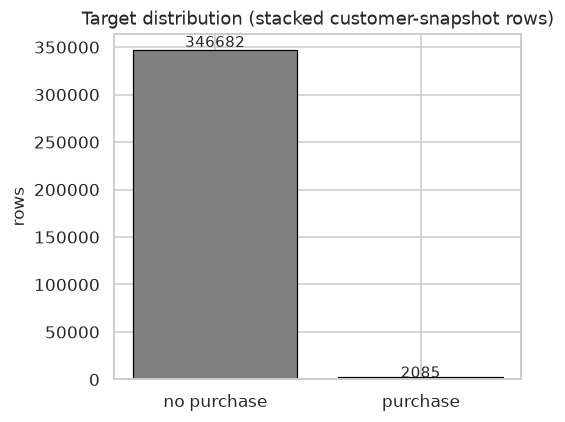

In [3]:
n = len(df)
k = int(y.sum())
rate = k / n
ci = proportion_confint(k, n, method="wilson")
print("positives:", str(k), "/", str(n), "=", str(round(100 * rate, 4)) + "%")
print("Wilson 95% CI:", str(round(100 * ci[0], 4)) + "% to " + str(round(100 * ci[1], 4)) + "%")
print("negatives:", str(n - k), "(" + str(round(100 * (1 - rate), 2)) + "%)")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["no purchase", "purchase"], [n - k, k], color=["grey", "steelblue"],
       edgecolor="black", linewidth=0.8)
ax.set_title("Target distribution (stacked customer-snapshot rows)")
ax.set_ylabel("rows")
for i, v in enumerate([n - k, k]):
    ax.text(i, v * 1.01, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

**Reading.** *Observed association:* n/a (univariate). *Statistical evidence:*
the positive rate is about 0.6% with a Wilson 95% CI only ~0.05pp wide —
prevalence is precisely estimated *in this stacked panel*. *Causal
interpretation:* none; this is a base rate, not an effect.

## 2. Class imbalance
Question: how severe is the imbalance, and what does it imply for later modelling?
(No modelling is done here — only quantification.)

imbalance ratio (neg:pos): 166.3 : 1
majority-class baseline accuracy: 99.4022%
A constant never-purchase classifier scores ~99.4%: accuracy is uninformative here.
Prevalence implies about 167 rows screened per expected positive.


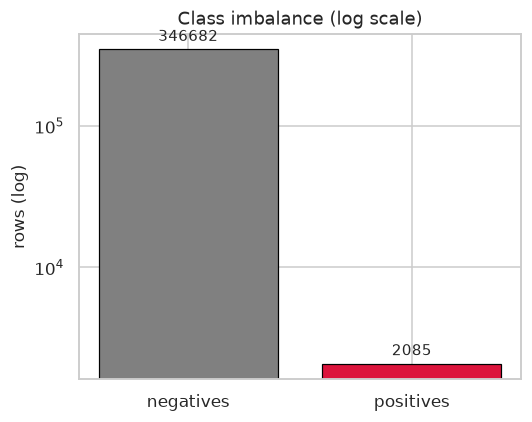

In [4]:
neg, pos = n - k, k
print("imbalance ratio (neg:pos):", str(round(neg / pos, 1)) + " : 1")
print("majority-class baseline accuracy:", str(round(100 * neg / n, 4)) + "%")
print("A constant never-purchase classifier scores ~99.4%: accuracy is uninformative here.")
print("Prevalence implies about", str(int(1 / rate)), "rows screened per expected positive.")

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["negatives", "positives"], [neg, pos], color=["grey", "crimson"],
       edgecolor="black", linewidth=0.8)
ax.set_yscale("log")
ax.set_title("Class imbalance (log scale)")
ax.set_ylabel("rows (log)")
for i, v in enumerate([neg, pos]):
    ax.text(i, v * 1.15, str(v), ha="center", fontsize=10)
plt.tight_layout()
plt.show()

**Reading.** *Observed:* roughly 167:1 imbalance; positives are rare events.
*Statistical evidence:* the Wilson CI in §1 shows prevalence is stable, not a
sampling fluke. *Causal interpretation:* none. Modelling implication (for a
later phase): use metrics suited to rare events (e.g. PR-AUC, recall at fixed
precision) and stratified/time-aware splits — accuracy would be misleading.

## 3. Feature distributions
Question: what do the marginal distributions look like (shape, skew,
zero-inflation, range)? Purely descriptive — no target involved.

skewness (descending):
avg_order_value_180d           10.547525
total_spend_180d               10.458701
purchase_count_180d             9.379073
avg_days_between_orders         1.882585
days_since_previous_purchase    1.871685
purchase_velocity_30d           1.546086
purchase_count_30d              1.546086
recency_days                    0.231272
purchase_velocity_90d          -0.055510
purchase_count_90d             -0.055510

zero share of windowed counts:
  purchase_count_30d equals 0: 79.01%
  purchase_count_90d equals 0: 41.72%
  purchase_count_180d equals 1: 97.75%
  rows with any gap history: 2.95%


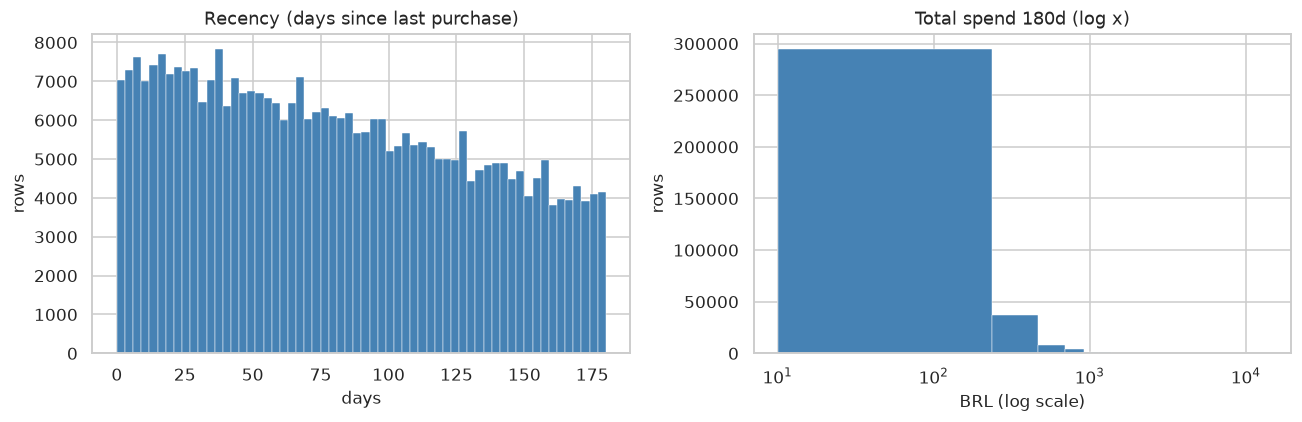

In [5]:
sk = df[FEATURES].skew().sort_values(ascending=False)
print("skewness (descending):")
print(sk.to_string())
print()
print("zero share of windowed counts:")
for c in ["purchase_count_30d", "purchase_count_90d"]:
    print(" ", c, "equals 0:", str(round(100 * (df[c] == 0).mean(), 2)) + "%")
print("  purchase_count_180d equals 1:", str(round(100 * (df["purchase_count_180d"] == 1).mean(), 2)) + "%")
print("  rows with any gap history:", str(round(100 * df["days_since_previous_purchase"].notna().mean(), 2)) + "%")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["recency_days"], bins=60, color="steelblue", edgecolor="white", linewidth=0.3)
axes[0].set_title("Recency (days since last purchase)")
axes[0].set_xlabel("days")
axes[0].set_ylabel("rows")
axes[1].hist(df["total_spend_180d"], bins=60, color="steelblue", edgecolor="white", linewidth=0.3)
axes[1].set_xscale("log")
axes[1].set_title("Total spend 180d (log x)")
axes[1].set_xlabel("BRL (log scale)")
axes[1].set_ylabel("rows")
plt.tight_layout()
plt.show()

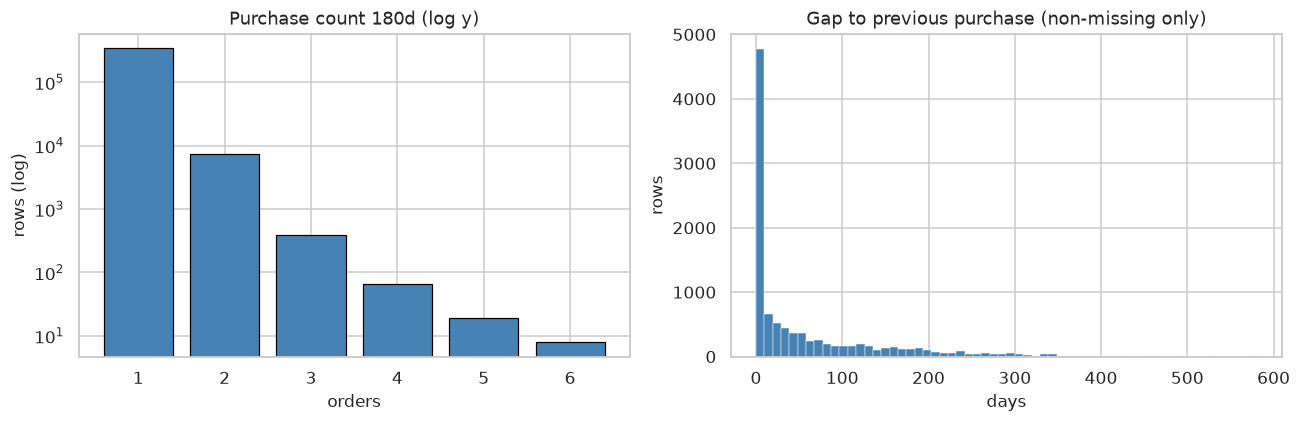

non-missing gap rows: 10279 | median gap (days): 14.1


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ct = df["purchase_count_180d"].value_counts().sort_index().head(6)
axes[0].bar(ct.index.astype(str), ct.values, color="steelblue", edgecolor="black", linewidth=0.8)
axes[0].set_yscale("log")
axes[0].set_title("Purchase count 180d (log y)")
axes[0].set_xlabel("orders")
axes[0].set_ylabel("rows (log)")
g = df.dropna(subset=["days_since_previous_purchase"])
axes[1].hist(g["days_since_previous_purchase"], bins=60, color="steelblue",
             edgecolor="white", linewidth=0.3)
axes[1].set_title("Gap to previous purchase (non-missing only)")
axes[1].set_xlabel("days")
axes[1].set_ylabel("rows")
plt.tight_layout()
plt.show()
print("non-missing gap rows:", len(g), "| median gap (days):", round(g["days_since_previous_purchase"].median(), 1))

**Reading.** *Observed:* recency spreads over 0–180d by construction (the cohort
always has an in-window purchase); counts are heavily zero/one-inflated; spend
is right-skewed; gap features exist for only ~3% of rows. *Statistical
evidence:* skewness values above quantify the asymmetry (counts/spend skew
near 10). *Causal interpretation:* none — these are marginals, unrelated to any
outcome yet.

## 4. Recency vs future purchase
Question: is a more recent last purchase associated with a higher repurchase rate?
Method: 30-day recency buckets, grouped rates + Wilson CIs, chi-square test of
independence across buckets with Cramer's V effect size.

                count  positives     rate    ci_lo    ci_hi
recency_bucket                                             
0-30            73199        656 0.008962 0.008304 0.009671
31-60           67953        428 0.006298 0.005731 0.006922
61-90           62110        315 0.005072 0.004543 0.005662
91-120          55085        287 0.005210 0.004642 0.005847
121-150         48672        228 0.004684 0.004116 0.005331
151-180         41748        171 0.004096 0.003527 0.004756
chi2(df=5) = 163.5 | p = 1.7868953807070906e-33
Cramers V = 0.0217 (conventionally a small association)


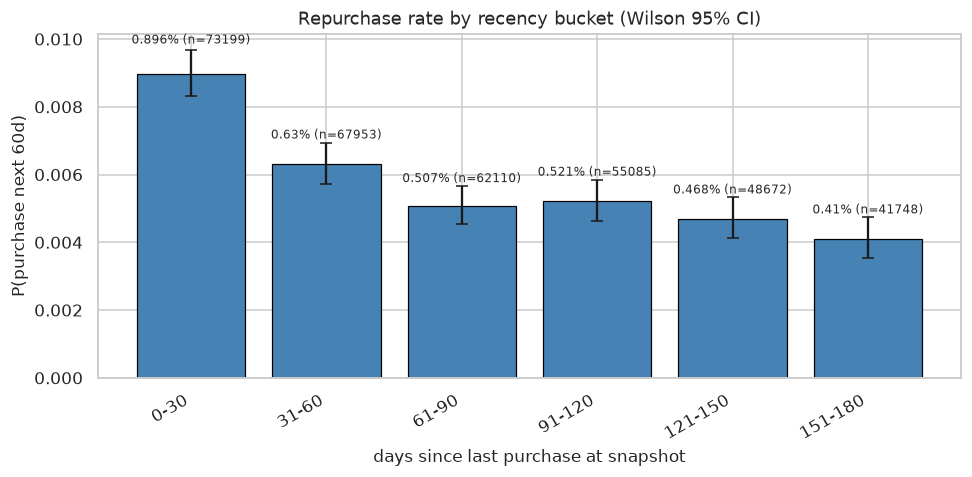

In [7]:
df["recency_bucket"] = pd.cut(df["recency_days"], bins=[0, 30, 60, 90, 120, 150, 180],
                              labels=["0-30", "31-60", "61-90", "91-120",
                                      "121-150", "151-180"], include_lowest=True)
rt = grouped_rates(df, "recency_bucket")
print(rt.to_string())
cont = pd.crosstab(df["recency_bucket"], y)
res = sstats.chi2_contingency(cont)
V = cramers_v(res[0], cont.values.sum(), cont.shape[0], cont.shape[1])
print("chi2(df=" + str(res[2]) + ") =", round(res[0], 1), "| p =", res[1])
print("Cramers V =", round(V, 4), "(conventionally a small association)")

fig, ax = plt.subplots(figsize=(9, 4.5))
rate_bar(ax, rt, "Repurchase rate by recency bucket (Wilson 95% CI)",
         "days since last purchase at snapshot")
plt.tight_layout()
plt.show()

**Reading.** *Observed association:* the repurchase rate falls as recency grows
(most-recent bucket roughly double the stalest). *Statistical evidence:*
chi-square rejects homogeneity across buckets, but Cramer's V is small — a
real but modest gradient. *Causal interpretation:* none — recency may proxy for
unmeasured churn, tenure or seasonality; intervening on "recency" is not even
well-defined.

## 5. Purchase frequency vs future purchase
Question: do customers who bought more often repurchase at higher rates?
Method: grouped rates for 180d counts (1 / 2 / 3+, pooling sparse cells so the
chi-square test stays valid), plus 30d/90d presence splits with two-proportion
z-tests, Newcombe risk-difference CIs and risk ratios.

             count  positives     rate    ci_lo    ci_hi
freq_group                                              
1           340930       1885 0.005529 0.005286 0.005784
2             7348        152 0.020686 0.017673 0.024199
3+             489         48 0.098160 0.074838 0.127746
chi2(df=2) = 978.3 | p = 3.6712912649211765e-213
Cramers V = 0.053
purchase_count_30d > 0 vs = 0: 0.896% vs 0.519% | risk ratio = 1.73 | risk diff 95% CI: 0.0031 to 0.0045 | z-test p = 4.905275616749914e-32
purchase_count_90d > 0 vs = 0: 0.688% vs 0.471% | risk ratio = 1.46 | risk diff 95% CI: 0.0017 to 0.0027 | z-test p = 2.6052883874319655e-16


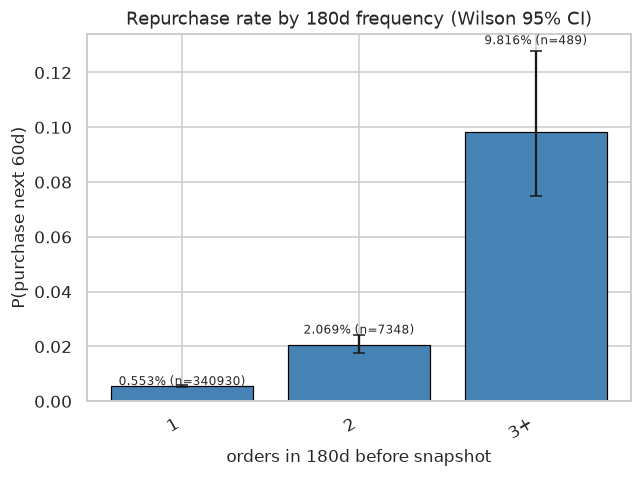

In [8]:
df["freq_group"] = np.where(df["purchase_count_180d"] >= 3, "3+",
                            df["purchase_count_180d"].astype(str))
ft = grouped_rates(df, "freq_group").reindex(["1", "2", "3+"])
print(ft.to_string())
cont = pd.crosstab(df["freq_group"], y).reindex(["1", "2", "3+"])
res = sstats.chi2_contingency(cont)
V = cramers_v(res[0], cont.values.sum(), cont.shape[0], cont.shape[1])
print("chi2(df=" + str(res[2]) + ") =", round(res[0], 1), "| p =", res[1])
print("Cramers V =", round(V, 4))

for window in (30, 90):
    col = "purchase_count_" + str(window) + "d"
    a = np.asarray(df[col] > 0)
    ka = int((y[a] == 1).sum())
    na = int(a.sum())
    kb = int((y[~a] == 1).sum())
    nb = int((~a).sum())
    ra, rb = ka / na, kb / nb
    pz = proportions_ztest([ka, kb], [na, nb])[1]
    dci = confint_proportions_2indep(ka, na, kb, nb, compare="diff", method="newcombe")
    print(col, "> 0 vs = 0:", str(round(100 * ra, 3)) + "% vs " + str(round(100 * rb, 3)) + "%",
          "| risk ratio =", round(ra / rb, 2),
          "| risk diff 95% CI:", str(round(dci[0], 4)) + " to " + str(round(dci[1], 4)),
          "| z-test p =", pz)

fig, ax = plt.subplots(figsize=(6, 4.5))
rate_bar(ax, ft, "Repurchase rate by 180d frequency (Wilson 95% CI)",
         "orders in 180d before snapshot")
plt.tight_layout()
plt.show()

**Reading.** *Observed association:* a steep frequency gradient — multi-order
customers repurchase at several times the rate of one-time buyers.
*Statistical evidence:* chi-square strongly rejects homogeneity and presence
splits show risk ratios materially above 1 with CIs excluding zero difference
(sparse top cells were pooled; high-count point estimates remain noisy).
*Causal interpretation:* none — frequent buyers differ in unmeasured ways
(loyalty, need, tenure); frequency is a marker, not a proven lever.

## 6. Monetary value vs future purchase
Question: do higher spenders / higher basket values repurchase more?
Method: spend and AOV quartile rates + CIs; Mann–Whitney U comparing the full
distributions of positives vs negatives (rank-based, robust to heavy skew),
with rank-biserial r and AUC = P(positive ranks above negative) as effect
sizes. Log-scale plots because spend spans orders of magnitude.

--- total_spend_180d quartiles ---
                   count  positives     rate    ci_lo    ci_hi
spend_q                                                       
(10.069, 62.59]    87316        502 0.005749 0.005269 0.006273
(62.59, 106.11]    87068        464 0.005329 0.004867 0.005835
(106.11, 179.0]    87203        513 0.005883 0.005397 0.006413
(179.0, 13664.08]  87180        606 0.006951 0.006421 0.007525
Mann-Whitney U = 375064372 | p = 0.0029039363970135143
rank-biserial r = 0.0378 | AUC = 0.5189 (0.5/0.0 = no separation)
median: total_spend_180d positives 113.15 vs negatives 106.07

--- avg_order_value_180d quartiles ---
                   count  positives     rate    ci_lo    ci_hi
AOV_q                                                         
(10.069, 61.91]    87193        514 0.005895 0.005408 0.006425
(61.91, 104.38]    87193        506 0.005803 0.005320 0.006330
(104.38, 175.5]    87196        519 0.005952 0.005463 0.006485
(175.5, 13664.08]  87185        546 0.006263 0.00

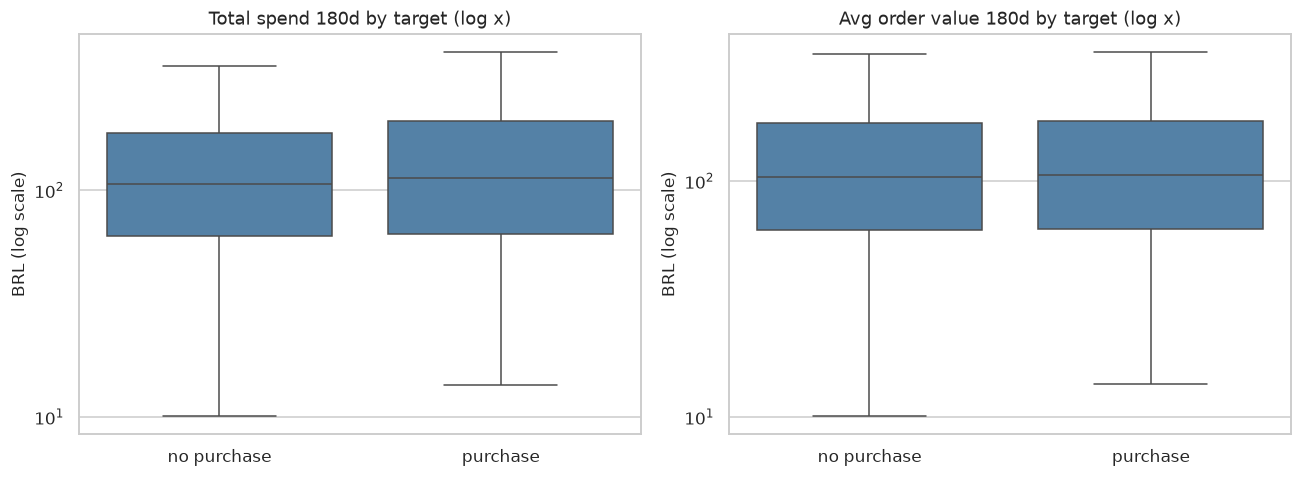

In [9]:
pairs = [("total_spend_180d", "spend"), ("avg_order_value_180d", "AOV")]
for col, name in pairs:
    df[name + "_q"] = pd.qcut(df[col], 4, duplicates="drop")
    t = grouped_rates(df, name + "_q")
    print("---", col, "quartiles ---")
    print(t.to_string())
    pos = df.loc[y == 1, col]
    neg = df.loc[y == 0, col]
    u, p, r_rb, auc = mw_effect(pos, neg)
    print("Mann-Whitney U =", str(int(u)), "| p =", p)
    print("rank-biserial r =", round(r_rb, 4), "| AUC =", round(auc, 4),
          "(0.5/0.0 = no separation)")
    print("median:", col, "positives", round(pos.median(), 2),
          "vs negatives", round(neg.median(), 2))
    print()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
panels = [("total_spend_180d", "Total spend 180d by target (log x)"),
          ("avg_order_value_180d", "Avg order value 180d by target (log x)")]
for ax, item in zip(axes, panels):
    sns.boxplot(data=df, x="purchased_next_60_days", y=item[0], ax=ax,
                color="steelblue", showfliers=False)
    ax.set_yscale("log")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["no purchase", "purchase"])
    ax.set_xlabel("")
    ax.set_ylabel("BRL (log scale)")
    ax.set_title(item[1])
plt.tight_layout()
plt.show()

**Reading.** *Observed association:* only a weak monetary gradient (top spend
quartile modestly above the rest; medians differ slightly) — far weaker than
the recency/frequency gradients. *Statistical evidence:* with ~349k rows the
Mann–Whitney tests can be significant while rank-biserial r / AUC stay near
their no-separation values, i.e. negligible distributional separation.
Significance here reflects sample size, not importance. *Causal
interpretation:* none — and the weakness of the gradient itself argues against
treating spend as a strong behavioural signal in this data.

## 7. Behavioural features vs target
Question: do short-window activity, velocity and repeat-purchase history relate
to repurchase? Method: (a) any-purchase-in-30d split; (b) repeat-history
(gap non-missing) split — each with z-test, risk ratio and Newcombe difference
CI; (c) gap-value distributions, positives vs negatives, via Mann–Whitney
(positive n is small — interpret cautiously).

bought in last 30d: 0.896% (n=73199) vs 0.519% (n=275568) | risk ratio = 1.73 | diff 95% CI: 0.0031 to 0.0045 | p = 4.905275616749914e-32
repeat-purchase history (gap known): 2.539% (n=10279) vs 0.539% (n=338488) | risk ratio = 4.71 | diff 95% CI: 0.0171 to 0.0232 | p = 4.255006931645898e-148
rows with gap history: 10279 (2.95%) | positives among them: 261
days_since_previous_purchase : pos median 27.1 d vs neg median 14.0 d | U p = 0.00012699996371225806 | r = 0.138 | AUC = 0.569
avg_days_between_orders : pos median 34.0 d vs neg median 15.6 d | U p = 3.711618104908495e-05 | r = 0.149 | AUC = 0.575


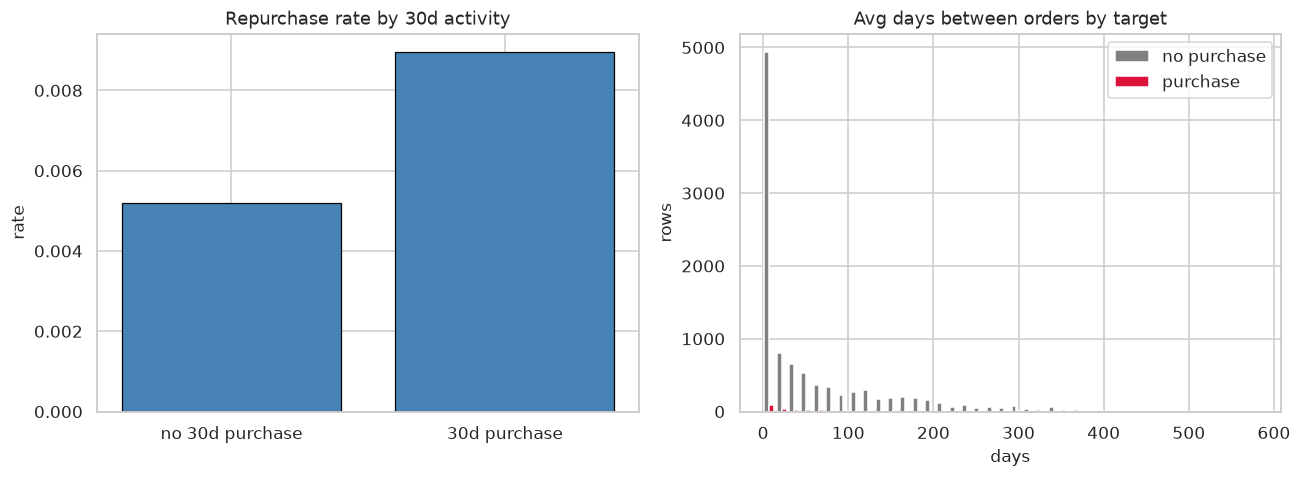

In [10]:
splits = {"bought in last 30d": np.asarray(df["purchase_count_30d"] > 0),
          "repeat-purchase history (gap known)":
              np.asarray(df["days_since_previous_purchase"].notna())}
for name, a in splits.items():
    ka = int((y[a] == 1).sum())
    na = int(a.sum())
    kb = int((y[~a] == 1).sum())
    nb = int((~a).sum())
    ra, rb = ka / na, kb / nb
    pz = proportions_ztest([ka, kb], [na, nb])[1]
    dci = confint_proportions_2indep(ka, na, kb, nb, compare="diff", method="newcombe")
    print(name + ":", str(round(100 * ra, 3)) + "% (n=" + str(na) + ") vs "
          + str(round(100 * rb, 3)) + "% (n=" + str(nb) + ")",
          "| risk ratio =", round(ra / rb, 2),
          "| diff 95% CI:", str(round(dci[0], 4)) + " to " + str(round(dci[1], 4)),
          "| p =", pz)

g = df.dropna(subset=["days_since_previous_purchase", "avg_days_between_orders"])
gp = int((g["purchased_next_60_days"] == 1).sum())
print("rows with gap history:", str(len(g)), "(" + str(round(100 * len(g) / len(df), 2)) + "%)",
      "| positives among them:", gp)
for col in ["days_since_previous_purchase", "avg_days_between_orders"]:
    pos = g.loc[g["purchased_next_60_days"] == 1, col]
    neg = g.loc[g["purchased_next_60_days"] == 0, col]
    u, p, r_rb, auc = mw_effect(pos, neg)
    print(col, ": pos median", round(pos.median(), 1), "d vs neg median",
          round(neg.median(), 1), "d | U p =", p, "| r =", round(r_rb, 3),
          "| AUC =", round(auc, 3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(["no 30d purchase", "30d purchase"],
            [y[df["purchase_count_30d"] == 0].mean(),
             y[df["purchase_count_30d"] > 0].mean()],
            color="steelblue", edgecolor="black", linewidth=0.8)
axes[0].set_title("Repurchase rate by 30d activity")
axes[0].set_ylabel("rate")
axes[1].hist([g.loc[g["purchased_next_60_days"] == 0, "avg_days_between_orders"],
              g.loc[g["purchased_next_60_days"] == 1, "avg_days_between_orders"]],
             bins=40, label=["no purchase", "purchase"], color=["grey", "crimson"])
axes[1].set_title("Avg days between orders by target")
axes[1].set_xlabel("days")
axes[1].set_ylabel("rows")
axes[1].legend()
plt.tight_layout()
plt.show()

**Reading.** *Observed association:* recent activity and known repeat history
coincide with markedly higher repurchase rates (repeat-history rows run several
times the base rate); among customers with a history, shorter average gaps tilt
toward repurchase. *Statistical evidence:* splits have CIs well clear of zero
difference, but gap-value comparisons rest on only a few hundred positives —
effect sizes are modest and uncertain. *Causal interpretation:* none — having a
repeat history is itself a marker of being an engaged customer, not a treatment.

## 8. Correlation analysis
Question: how do features relate to each other and to the target?
Method: Spearman rank correlations (robust to skew, zero-inflation and the
derived count/velocity identities). Note structural collinearity by design:
counts are nested windows (30d within 90d within 180d) and velocities are
deterministic rescalings of counts — high correlations there are arithmetic,
not discovery.

Spearman correlation with target (descending):
avg_days_between_orders         0.040686
purchase_count_180d             0.038638
days_since_previous_purchase    0.037800
purchase_count_30d              0.020531
purchase_velocity_30d           0.020531
purchase_count_90d              0.017962
purchase_velocity_90d           0.017962
total_spend_180d                0.005042
avg_order_value_180d           -0.000156
recency_days                   -0.020727


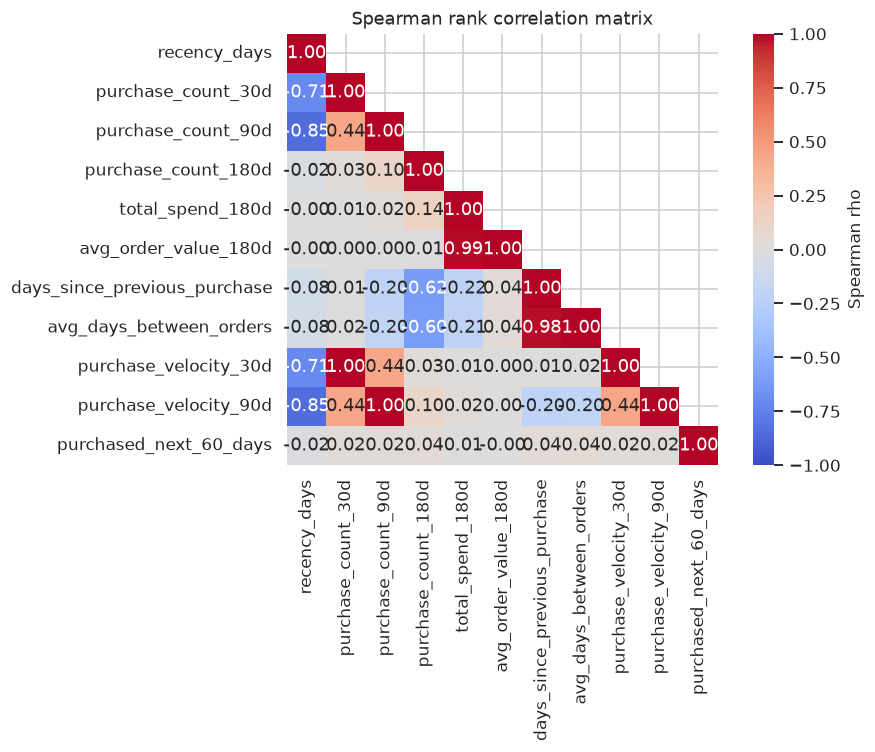

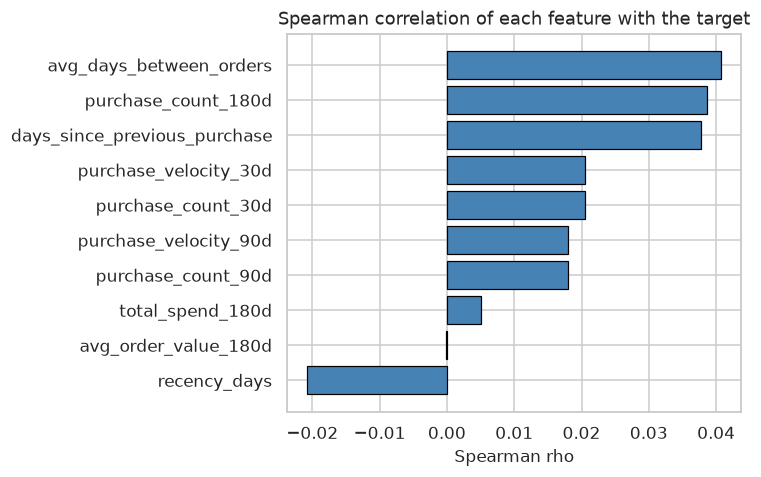

In [11]:
corr = df[FEATURES + ["purchased_next_60_days"]].corr(method="spearman")
print("Spearman correlation with target (descending):")
tc = corr["purchased_next_60_days"].drop("purchased_next_60_days").sort_values(ascending=False)
print(tc.to_string())

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1,
            vmax=1, square=True, cbar_kws={"label": "Spearman rho"}, ax=ax)
ax.set_title("Spearman rank correlation matrix")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
asc = tc.sort_values()
ax.barh(asc.index, asc.values, color="steelblue", edgecolor="black", linewidth=0.8)
ax.set_title("Spearman correlation of each feature with the target")
ax.set_xlabel("Spearman rho")
plt.tight_layout()
plt.show()

**Reading.** *Observed:* frequency/behavioural features correlate positively
with the target and recency negatively; monetary correlations sit near zero.
Exact duplicates appear where definitions force them: each velocity is a
rescaling of its count (rho = 1.0), and spend/AOV track each other at rho
approx 0.99 (most rows are single-order, where they coincide) — while nested
count windows correlate only modestly in rank terms (sparse, heavily tied).
*Statistical evidence:* rank correlations on ~349k rows are precisely estimated
but all |rho| <= 0.04 with the target. *Causal interpretation:* none. Later
modelling should drop the exact duplicates (one of each velocity/count pair;
one of spend/AOV) — a modelling note, not a finding about customers.

## 9. Temporal target stability
Question: is the repurchase rate stable across the 15 monthly snapshots, or does
it drift (which would threaten a pooled model)? Method: per-snapshot rates with
Wilson CIs, chi-square homogeneity test across snapshots with Cramer's V — read
descriptively, since snapshots share customers (repeated measures, so the
independence assumption fails and the test overstates precision).

               count  positives     rate    ci_lo    ci_hi
snapshot_date                                             
2017-04-01      5111         31 0.006065 0.004276 0.008596
2017-05-01      7106         50 0.007036 0.005342 0.009264
2017-06-01     10557         72 0.006820 0.005420 0.008579
2017-07-01     13594         78 0.005738 0.004600 0.007155
2017-08-01     16582        101 0.006091 0.005016 0.007395
2017-09-01     18805        128 0.006807 0.005728 0.008087
2017-10-01     20444        146 0.007141 0.006076 0.008392
2017-11-01     22313        161 0.007216 0.006187 0.008414
2017-12-01     26093        176 0.006745 0.005822 0.007813
2018-01-01     28365        157 0.005535 0.004736 0.006468
2018-02-01     31340        173 0.005520 0.004758 0.006403
2018-03-01     34069        192 0.005636 0.004895 0.006488
2018-04-01     36783        213 0.005791 0.005065 0.006619
2018-05-01     39229        215 0.005481 0.004797 0.006261
2018-06-01     38376        192 0.005003 0.004345 0.0057

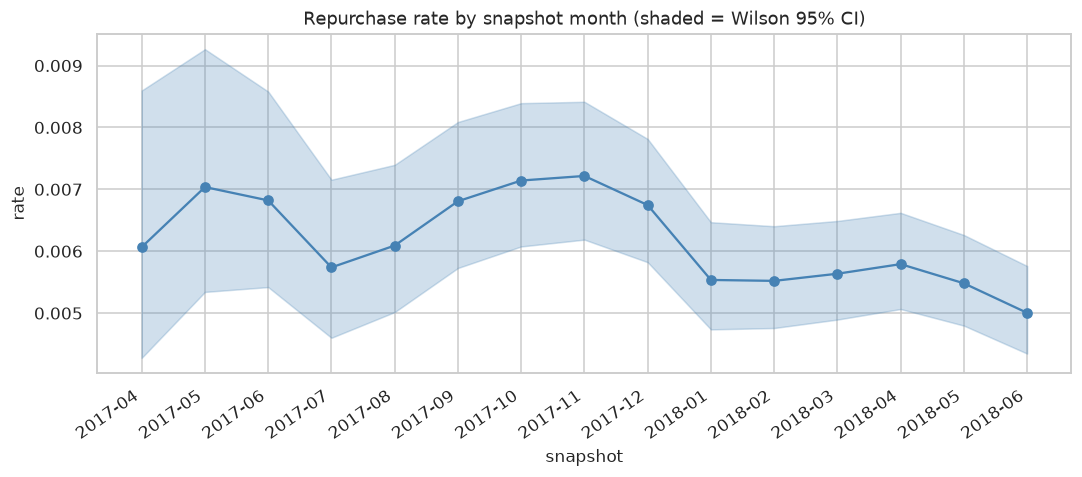

In [12]:
st = grouped_rates(df, "snapshot_date")
print(st.to_string())
cont = pd.crosstab(df["snapshot_date"], y)
res = sstats.chi2_contingency(cont)
V = cramers_v(res[0], cont.values.sum(), cont.shape[0], cont.shape[1])
print("chi2(df=" + str(res[2]) + ") =", round(res[0], 1), "| p =", res[1])
print("Cramers V =", round(V, 4))
print("range of snapshot rates:",
      str(round(100 * st["rate"].min(), 3)) + "% to " + str(round(100 * st["rate"].max(), 3)) + "%")

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(st))
ax.plot(x, st["rate"], marker="o", color="steelblue")
ax.fill_between(x, st["ci_lo"], st["ci_hi"], alpha=0.25, color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels([d.strftime("%Y-%m") for d in st.index], rotation=35, ha="right")
ax.set_title("Repurchase rate by snapshot month (shaded = Wilson 95% CI)")
ax.set_ylabel("rate")
ax.set_xlabel("snapshot")
plt.tight_layout()
plt.show()

**Reading.** *Observed association:* snapshot rates sit in a narrow band
(roughly 0.5–0.7%) with no visible trend while the cohort grows.
*Statistical evidence:* cross-snapshot differences are tiny in absolute terms
(small Cramer's V); any formal "significance" would largely reflect the huge
stacked N and shared customers, not meaningful drift. *Causal interpretation:*
none — stability here only means the pooled base rate is not obviously
confounded by calendar time at monthly resolution.

## 10. Outliers
Question: where are the extreme values, how many rows do they touch, and do
outlier rows repurchase at different rates? Method: Tukey IQR upper fences per
numeric feature (a flagging rule, not a distributional test — no normality
assumed), outlier-row share, and outlier vs overall target rates with Wilson CIs
for description only. Nothing is removed: this phase only characterises.

              feature  outlier_rows  share outlier_rate outlier_rate_CI95
         recency_days             0 0.000%            -                 -
   purchase_count_30d             0 0.000%            -                 -
   purchase_count_90d           189 0.054%      12.169% 8.247% to 17.598%
  purchase_count_180d             0 0.000%            -                 -
     total_spend_180d         27834 7.981%       0.686%   0.596% to 0.79%
 avg_order_value_180d         27376 7.849%       0.486%   0.41% to 0.575%
purchase_velocity_30d             0 0.000%            -                 -
purchase_velocity_90d           189 0.054%      12.169% 8.247% to 17.598%
overall rate for reference: 0.598%
highest-spend row: snapshot 2017-10-01 | count_180d 1 | spend 13664.08 | AOV 13664.08 | target 0


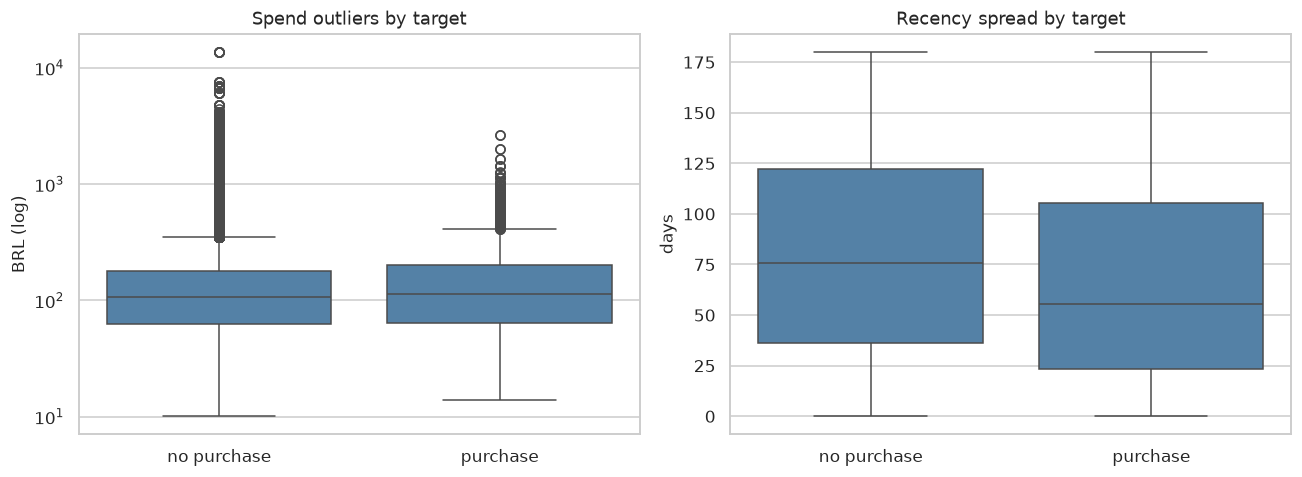

In [13]:
num_cols = ["recency_days", "purchase_count_30d", "purchase_count_90d",
            "purchase_count_180d", "total_spend_180d", "avg_order_value_180d",
            "purchase_velocity_30d", "purchase_velocity_90d"]
rows = []
for col in num_cols:
    qs = df[col].quantile([0.25, 0.75])
    iqr = float(qs.iloc[1] - qs.iloc[0])
    if iqr == 0:
        rows.append([col, 0, "0.000%", "-", "-"])
        continue
    flag = np.asarray(df[col] > qs.iloc[1] + 1.5 * iqr)
    m = int(flag.sum())
    if m == 0:
        rows.append([col, 0, "0.000%", "-", "-"])
        continue
    kk = int((y[flag] == 1).sum())
    ci = proportion_confint(kk, m, method="wilson")
    rows.append([col, m, str(round(100 * m / len(df), 3)) + "%",
                 str(round(100 * kk / m, 3)) + "%",
                 str(round(100 * ci[0], 3)) + "% to " + str(round(100 * ci[1], 3)) + "%"])
out = pd.DataFrame(rows, columns=["feature", "outlier_rows", "share",
                                  "outlier_rate", "outlier_rate_CI95"])
print(out.to_string(index=False))
print("overall rate for reference:", str(round(100 * y.mean(), 3)) + "%")
top = df.loc[df["total_spend_180d"].idxmax()]
print("highest-spend row: snapshot", str(top["snapshot_date"].date()),
      "| count_180d", top["purchase_count_180d"],
      "| spend", round(top["total_spend_180d"], 2),
      "| AOV", round(top["avg_order_value_180d"], 2),
      "| target", top["purchased_next_60_days"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=df, x="purchased_next_60_days", y="total_spend_180d", ax=axes[0],
            color="steelblue", showfliers=True)
axes[0].set_yscale("log")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["no purchase", "purchase"])
axes[0].set_xlabel("")
axes[0].set_ylabel("BRL (log)")
axes[0].set_title("Spend outliers by target")
sns.boxplot(data=df, x="purchased_next_60_days", y="recency_days", ax=axes[1],
            color="steelblue")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["no purchase", "purchase"])
axes[1].set_xlabel("")
axes[1].set_ylabel("days")
axes[1].set_title("Recency spread by target")
plt.tight_layout()
plt.show()

**Reading.** *Observed:* extremes concentrate in spend/AOV (long right tail)
and multi-order counts; recency has no upper-fence outliers at all — it is
bounded at 180d by the snapshot design, so the Tukey rule cannot flag any.
IQR is degenerate (zero) for the sparsest count/velocity columns. Outlier rows
are a small share of the panel. *Statistical evidence:* outlier-group rate CIs
are wide (small n) — directional differences vs the base rate are noted, not
established. *Causal interpretation:* none. Handling (winsorise / log-transform
/ keep) is deferred to modelling; no rows are altered here.

## Key Findings (results only — no causal claims)

1. **Repurchase is a rare event.** 2,085 of 348,767 stacked rows repurchased
   within 60 days: 0.60% (Wilson 95% CI 0.57–0.62%), i.e. ~166:1 imbalance
   across 75,386 customers (median 5 snapshots each). A never-purchase rule
   scores 99.40% accuracy, so accuracy is uninformative and later modelling
   needs rare-event metrics with stratified, time-aware splits.
2. **Purchase frequency is the strongest signal.** Rates rise 0.55% (1 order)
   → 2.07% (2) → 9.82% (3+) with the largest grouping effect observed
   (chi-square Cramer's V = 0.053); any-30d-activity RR = 1.7, any-90d RR = 1.5.
   Volume caveat: 90.4% of all positives (1,885/2,085) are single-order rows —
   the high-rate groups are small (48 positives in 3+).
3. **Recency gradient is real but modest.** 0.90% (0–30d) → 0.41% (151–180d),
   Cramer's V = 0.022: roughly a doubling from stalest to freshest bucket.
4. **Repeat history marks engagement — with a nuance.** Rows with a known
   repeat history repurchase at 2.54% vs 0.54% (risk ratio 4.7, difference CI
   1.7–2.3pp). Yet *within* history-holders, positives show *longer* median
   gaps (last gap 27.1 vs 14.0d; average gap 34.0 vs 15.6d; MW p ≈ 1e-4,
   r ≈ 0.14) — a descriptive pattern on only 261 positives, not a lever.
5. **Money barely separates.** Spend quartiles span 0.53–0.70%; the spend
   Mann–Whitney test is significant (p = 0.003) only by dint of N
   (AUC = 0.519, rank-biserial r = 0.04). AOV shows nothing at all
   (AUC = 0.499, p = 0.93; quartiles 0.58–0.63%).
6. **All univariate signals are weak; some features are exact duplicates.**
   Every feature–target Spearman |rho| ≤ 0.04 (top: avg gap +0.041, count_180d
   +0.039, recency −0.021; monetary ≈ 0). Velocities duplicate their counts
   (rho = 1.0) and spend duplicates AOV (rho ≈ 0.99, single-order rows) — drop
   one of each pair when modelling. Nested count windows correlate only
   modestly in rank terms due to sparsity.
7. **The target is temporally stable.** Monthly snapshot rates sit in
   0.50–0.72% with no trend (Cramer's V = 0.009); the chi-square p = 0.012
   reflects the huge stacked N and customers shared across snapshots, not
   meaningful drift — pooling snapshots for modelling is defensible.
8. **Outliers are characterised, nothing removed.** The spend tail (27.8k rows,
   8%) repurchases at 0.69% ≈ base rate; 189 high-frequency outliers sit at
   12.2% but with CI 8.2–17.6% (tiny n); the max-spend row (13,664 BRL, one
   order) is negative; recency has no upper outliers by design (bounded 180d).
9. **Limits.** Rows are non-independent (shared customers across snapshots),
   so p-values are optimistic — findings lean on effect sizes and CIs. No
   confounder adjustment was performed, gap-value results rest on 2.95% of
   rows, and no causal interpretation is warranted for any association above.


## Limitations and next steps (no ML in this phase)
- Stacked-panel non-independence (shared customers across snapshots) makes all
  p-values optimistic; conclusions lean on effect sizes and CIs.
- No confounder adjustment — all relationships are unadjusted associations.
- Gap-value analyses rest on ~3% of rows (few hundred positives): uncertain.
- Suggested later work: time-aware validation splits, rare-event metrics,
  handling of redundant window features and skew — modelling, out of scope here.